In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from skimage import io

In [2]:
def NBR(NIRband,SWIRband):
    '''Calculation of the Normalized Burned Ratio
    **input**
    1) NIRband: image in the NIR band
    2) SWIRband: image in the SWIR band
    **output**
     NBR coefficient'''
    NIRband = NIRband.astype(np.float32)
    SWIRband = SWIRband.astype(np.float32)
    return (NIRband-SWIRband)/(NIRband+SWIRband+1e-10)

def dNBR(prefire,postfire):
    '''Calculation of the severity level
    **input**
    1) prefire: NBR of prefire image
    2) postfire: NBR of postfire image
    **output**
      '''
    return prefire-postfire


def RdNBR(dNBR, NBR_prefire):
    return dNBR/(np.abs(NBR_prefire)+0.001)**0.5

def Kmeans_segmentation(im,low_lim,upper_lim):
    #primer acotem la regió i filtrem a la zona cremada
    mask = (im>low_lim)&(im<upper_lim)
    filt_im = im[mask].reshape(-1,1)
    #entrenem els píxels cremats
    #data_P_S = np.reshape(filtered_RdNBR, (-1,1))
    mostra = shuffle(filt_im, random_state=0)[:1000] #mostra per accelerar entrenament
    kmn = KMeans(n_clusters=3, init='k-means++',random_state=0).fit(mostra) #entrenament
    labels = kmn.predict(filt_im) #etiquetar
    centroids = kmn.cluster_centers_
    #reconstrucció de la imatge
    im_Kmeans = np.zeros(im.shape,dtype=int)
    im_Kmeans[mask] = labels + 1
    return im_Kmeans



In [3]:
#---------------------------------------------------------Incendi de Paüls (imP) 03/06/2024------------------------------------------------------------------
#---------------------------------------------------------Setinel pre----------------------------------------------------------------------------------------
img_b8a_pre = io.imread("../database/Pont_Vilomara_2022/SENTINEL/2022-07-16-Sentinel-2_L2A_B8A_(Raw).tiff")
img_b12_pre = io.imread("../database/Pont_Vilomara_2022/SENTINEL/2022-07-16-Sentinel-2_L2A_B12_(Raw).tiff")
img_b8a_post = io.imread("../database/Pont_Vilomara_2022/SENTINEL/2022-07-19-Sentinel-2_L2A_B8A_(Raw).tiff")
img_b12_post = io.imread("../database/Pont_Vilomara_2022/SENTINEL/2022-07-19-Sentinel-2_L2A_B12_(Raw).tiff")

Creamos NBR

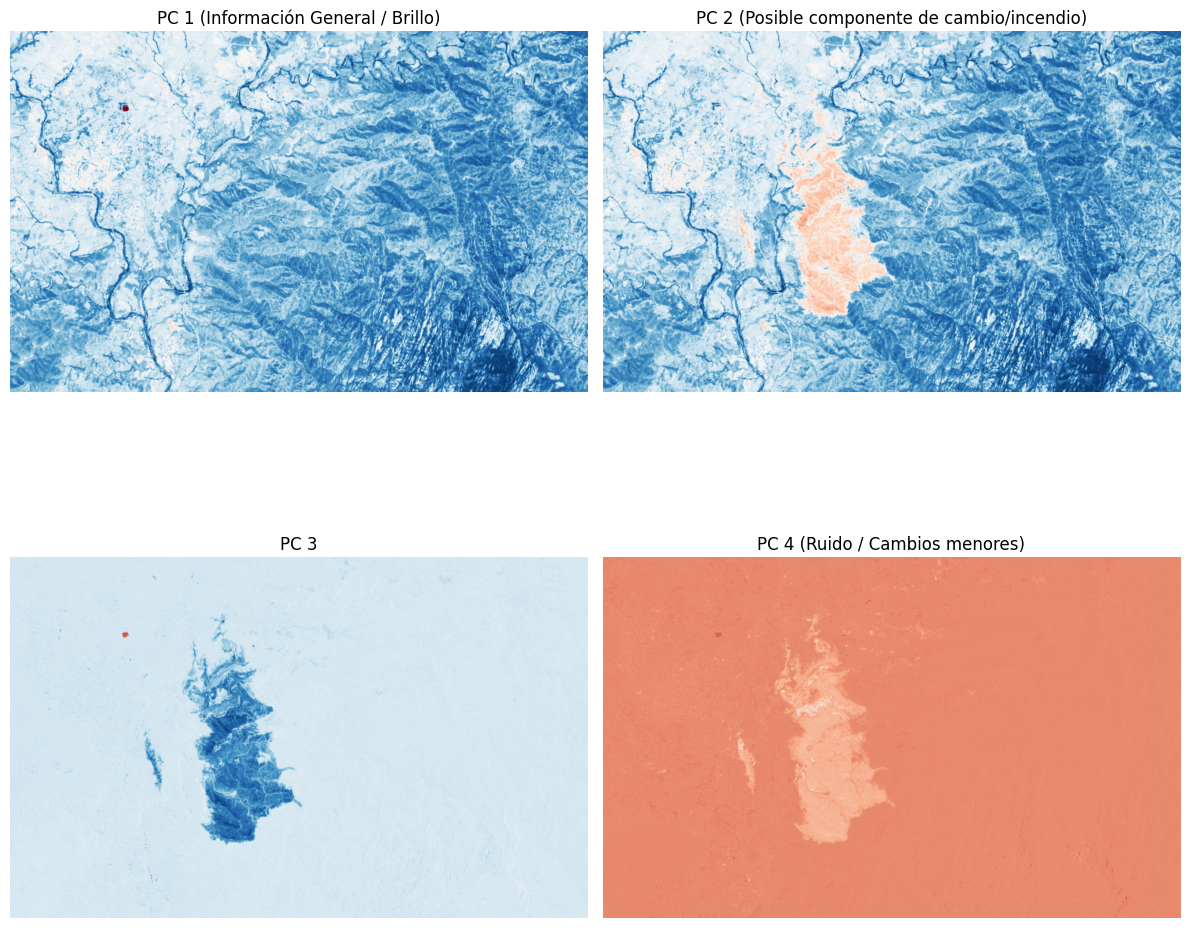

In [9]:
NBR_pre  = NBR(img_b8a_pre, img_b12_pre)
NBR_post = NBR(img_b8a_post, img_b12_post)
dNBR_    = dNBR(NBR_pre, NBR_post)
RdNBR_   = RdNBR(dNBR_, NBR_pre)
# --- 5. Visualizar los resultados ---
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(NBR_pre, cmap='RdBu')
axes[0, 0].set_title('PC 1 (Información General / Brillo)')

axes[0, 1].imshow(NBR_post, cmap='RdBu') # Mapa de color divergente útil para cambios
axes[0, 1].set_title('PC 2 (Posible componente de cambio/incendio)')

axes[1, 0].imshow(dNBR_, cmap='RdBu')
axes[1, 0].set_title('PC 3')

axes[1, 1].imshow(RdNBR_, cmap='RdBu')
axes[1, 1].set_title('PC 4 (Ruido / Cambios menores)')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()

In [ ]:
flat_8A_pre = imP_S_B8A_pre.reshape(1,-1)
flat_12_pre = imP_S_B12_pre.reshape(1,-1)
flat_8A_post = imP_S_B8A_post.reshape(1,-1)
flat_12_post = imP_S_B12_post.reshape(1,-1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- 0. Supongamos que tus variables ya están cargadas como arrays de numpy ---
# img_b8a_pre, img_b12_pre, img_b8a_post, img_b12_post 
# Todas deben tener la forma (1250, 1198)

img_b8a_pre = io.imread("../database/Pont_Vilomara_2022/SENTINEL/2022-07-16-Sentinel-2_L2A_B8A_(Raw).tiff")
img_b12_pre = io.imread("../database/Pont_Vilomara_2022/SENTINEL/2022-07-16-Sentinel-2_L2A_B12_(Raw).tiff")
img_b8a_post = io.imread("../database/Pont_Vilomara_2022/SENTINEL/2022-07-19-Sentinel-2_L2A_B8A_(Raw).tiff")
img_b12_post = io.imread("../database/Pont_Vilomara_2022/SENTINEL/2022-07-19-Sentinel-2_L2A_B12_(Raw).tiff")

print(img_b12_post.shape)

alto, ancho = 1562, 2500

# --- 1. Aplanar las imágenes y apilarlas en columnas ---
# Usamos .ravel() para convertir cada matriz de 2D a 1D (un vector largo)
# np.column_stack creará la matriz de tamaño (1497500, 4)
X = np.column_stack([
    img_b8a_pre.ravel(),
    img_b12_pre.ravel(),
    img_b8a_post.ravel(),
    img_b12_post.ravel()
])

print("Forma de la matriz de datos para el PCA:", X.shape)  # Debería ser (1497500, 4)

# --- 2. Normalización de los datos ---
# El PCA es muy sensible a las escalas de los datos. Como las reflectancias pre y post
# pueden variar por condiciones atmosféricas o iluminación, es CRUCIAL estandarizarlas.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Aplicar el PCA ---
# Queremos extraer las 4 componentes principales posibles
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# Ver cuánta información (varianza) captura cada componente
for i, varianza in enumerate(pca.explained_variance_ratio_):
    print(f"Componente Principal {i+1} explica el: {varianza * 100:.2f}% de la varianza")

# --- 4. Reestructurar los resultados a la forma de la imagen original ---
# Cada columna de X_pca corresponde a una Componente Principal (PC)
pc1 = X_pca[:, 0].reshape((alto, ancho))
pc2 = X_pca[:, 1].reshape((alto, ancho))
pc3 = X_pca[:, 2].reshape((alto, ancho))
pc4 = X_pca[:, 3].reshape((alto, ancho))

# --- 5. Visualizar los resultados ---
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(pc1, cmap='gray')
axes[0, 0].set_title('PC 1 (Información General / Brillo)')

axes[0, 1].imshow(pc2, cmap='RdBu') # Mapa de color divergente útil para cambios
axes[0, 1].set_title('PC 2 (Posible componente de cambio/incendio)')

axes[1, 0].imshow(pc3, cmap='RdBu')
axes[1, 0].set_title('PC 3')

axes[1, 1].imshow(pc4, cmap='RdBu')
axes[1, 1].set_title('PC 4 (Ruido / Cambios menores)')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.savefig('componentes_principales_incendio.png')

In [ ]:
print(len(pc1))

In [ ]:
from sklearn.cluster import KMeans

# 1. Seleccionar la componente que muestra el incendio y aplanarla
# (K-Means necesita un vector columna)
pc_seleccionada = pc3.reshape(-1, 1)

# 2. Definir el número de clases (por ejemplo, 4 clases de severidad)
n_clases = 4
kmeans = KMeans(n_clusters=n_clases, random_state=42, n_init=10)
clústeres_planos = kmeans.fit_predict(pc_seleccionada)

# 3. Reestructurar el resultado a la forma de la imagen original
mapa_severidad = clústeres_planos.reshape((alto, ancho))

In [ ]:
# Encontrar el valor medio de la PC para cada clúster
medias = [pc3[mapa_severidad == i].mean() for i in range(n_clases)]

# Ordenar los índices de los clústeres de menor a mayor media
indices_ordenados = np.argsort(medias)

# Crear un mapa nuevo con las clases ordenadas correctamente (0=No afectado, 3=Severidad Alta)
mapa_severidad_ordenado = np.zeros_like(mapa_severidad)
for nueva_etiqueta, vieja_etiqueta in enumerate(indices_ordenados):
    mapa_severidad_ordenado[mapa_severidad == vieja_etiqueta] = nueva_etiqueta

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(mapa_severidad_ordenado, cmap='YlOrRd') # De amarillo a rojo para severidad
plt.colorbar(label='Nivel de Severidad (0 a 3)')
plt.title('Mapa de Severidad No Supervisado (PCA + K-Means)')
plt.axis('off')
plt.show()

In [ ]:
# 1. Creamos una máscara donde se OCULTAN los valores menores que 2 (es decir, 0 y 1)
# La condición es: enmascarar si el valor es < 2
mapa_filtrado = np.ma.masked_where(mapa_severidad_ordenado < 2, mapa_severidad_ordenado)

# 2. Visualizar el mapa
plot.figure(figsize=(8, 8))

# Usamos una paleta de colores adecuada (ej. 'YlOrRd' o 'Reds')
# Matplotlib automáticamente no pintará (dejará transparente) lo que esté enmascarado
plot.imshow(mapa_filtrado, cmap="YlOrRd")

plot.title("Zonas de Severidad Moderada y Alta (Valores 2 y 3)")
plot.colorbar(label="Nivel de Severidad")
plot.axis("off")
plot.show()